# 09 — Quantile Regression (q10 / q50 / q75 / q90) และการเตือน

ผลทั้งหมดมาจาก `python -m src.quantile` ใช้เฉพาะข้อมูล 2023–2024 **ไม่ได้โหลดข้อมูลปี 2025**
โมเดลคือ XGBoost `reg:quantileerror` ที่ทำนาย CMF_UVI (params ที่ tune ในวัน 8, weight `uvi_clear²`) แล้วแปลงเป็น UVI = `uvi_clear` × quantile

**กฎที่ประกาศไว้ก่อนดูผล (แผนวัน 9):**
1. ช่วง [q10, q90] ผ่านถ้า coverage บน CV fold 3–5 (รวมกัน) อยู่ใน **0.75–0.85** ถ้าไม่ผ่านให้ใช้ **CQR** (split conformal)
   - E = max(q10 − y, y − q90) บนสเกล CMF แล้วขยายช่วงเป็น [q10 − Q, q90 + Q]
   - ตรวจโดย calibrate ด้วย fold 3–4 แล้วทดสอบบน fold 5
   - dev 2024 ใช้ Q จาก fold 1–2 (ปี 2023) และโมเดลสุดท้ายใช้ Q จาก fold 3–5
2. **การเตือน:** เตือนระดับ L เมื่อระดับ WHO ของ quantile ที่เลือก ≥ L เลือก quantile **ต่ำสุด** จาก q50 / q75 / q90 ที่ recall ระดับ**รุนแรงมาก** ≥ 0.8 **และ** precision ของการเตือนระดับ**สูงมากขึ้นไป** ≥ 0.5 บน CV fold 3–5 ถ้าไม่มีตัวไหนผ่านให้รายงานตามจริงแล้วใช้ q90 ตาม rules
   - q90 หมายถึงขอบบนที่ส่งให้ผู้ใช้จริง (หลัง CQR)
   - false alarm rate = FP / จำนวนชั่วโมงที่ระดับจริงต่ำกว่า L

⚠️ ตัวเลข dev 2024 มี optimistic bias จากการ tune ในวัน 8 ตัวเลขจริงคือ test 2025 ในวัน 10

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

In [2]:
import json

from xgboost import XGBRegressor

from src import quantile as qr
from src.splits import chronological_split, load_model_data
from src.train_cmf import MODEL_DIR, load_spec

docs = ROOT / "docs"
m = json.loads((MODEL_DIR / "cmf_uvi_quantile_xgb_v1_metrics.json").read_text(encoding="utf-8"))
cv_folds = pd.read_csv(docs / "quantile_cv_folds.csv")
dev_tab = pd.read_csv(docs / "quantile_dev_2024.csv")
alerts_cv = pd.read_csv(docs / "quantile_alerts_cv_folds3-5.csv")
alerts_dev = pd.read_csv(docs / "quantile_alerts_dev_2024.csv")
print(f"raw CV coverage (folds 3-5): {m['raw_cv_coverage']:.3f}; CQR applied: {m['cqr']['applied']}")
print(f"Q final {m['cqr']['q_final_cmf']:+.4f}, Q dev {m['cqr']['q_dev_cmf']:+.4f} (CMF)")
print("alert quantile:", m["alert_quantile"], "| passed:", m["alert_rule_passed"])
print(m["alert_reason"])

raw CV coverage (folds 3-5): 0.593; CQR applied: True
Q final +0.0379, Q dev +0.0503 (CMF)
alert quantile: q90 | passed: False
q50: Extreme recall 0.113, >=Very high precision 0.765; q75: Extreme recall 0.132, >=Very high precision 0.732; q90: Extreme recall 0.623, >=Very high precision 0.596 -> none passes, fall back to q90 (project rule)


## 1. Coverage ของช่วง [q10, q90]

In [3]:
chk = m["cqr"]["check"]
rows = [
    ("CV fold 3–5 raw", m["cv_folds_3_5"]["raw"]["interval"]),
    ("fold 5 raw", chk["fold5_raw"]),
    ("fold 5 CQR (Q from folds 3–4)", chk["fold5_cqr"]),
    ("dev 2024 raw", m["dev_2024"]["raw"]["interval"]),
    ("dev 2024 CQR (Q from 2023)", m["dev_2024"]["served"]["interval"]),
]
cov = pd.DataFrame({k: v for k, v in rows}).T[["n", "coverage", "below", "above", "width"]]
cov.round(3)

,n,coverage,below,above,width
CV fold 3–5 raw,3717.0,0.593,0.234,0.172,0.842
fold 5 raw,1239.0,0.652,0.182,0.165,0.790
fold 5 CQR (Q from folds 3–4),1239.0,0.863,0.094,0.044,1.328
dev 2024 raw,3726.0,0.578,0.249,0.173,0.814
dev 2024 CQR (Q from 2023),3726.0,0.837,0.121,0.042,1.502


,group,n_raw,coverage_raw,below_raw,above_raw,width_raw,n_cqr,coverage_cqr,below_cqr,above_cqr,width_cqr
0,Low,1256,0.673,0.285,0.042,0.367,1256,0.857,0.138,0.005,0.566
1,Moderate,857,0.658,0.170,0.172,0.882,857,0.883,0.082,0.035,1.496
2,High,835,0.502,0.255,0.243,1.092,835,0.826,0.120,0.054,2.062
3,Very high,768,0.422,0.271,0.307,1.158,768,0.764,0.138,0.098,2.412
4,Extreme,10,0.100,0.400,0.500,1.369,10,0.700,0.300,0.000,2.779


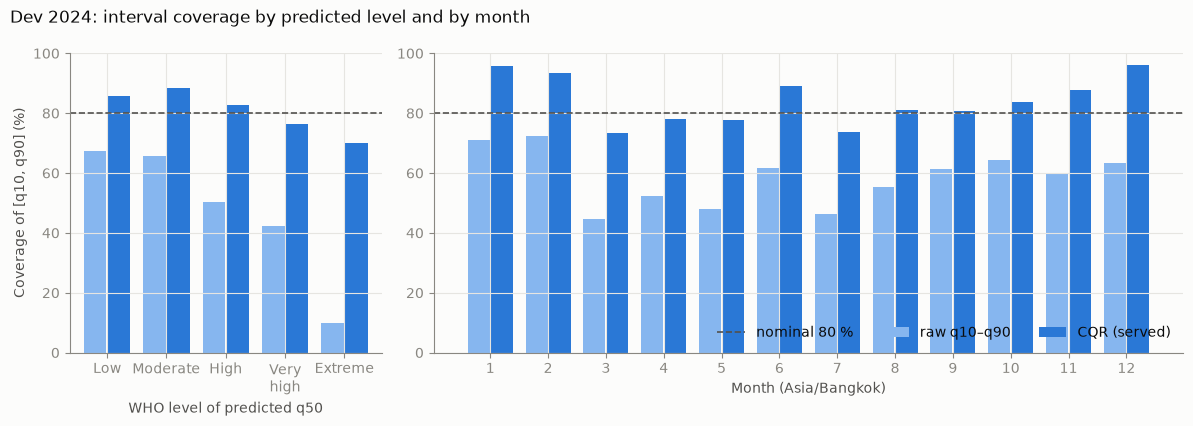

In [4]:
data = load_model_data()
train, dev = chronological_split(data)
features = load_spec()["features"]
model = XGBRegressor()
model.load_model(qr.MODEL_PATH)
dev_raw = qr.predict_quantiles(model, dev[features])
dev_q = qr.apply_cqr(dev_raw, m["cqr"]["q_dev_cmf"])
uvi_raw, uvi_q = qr.to_uvi(dev, dev_raw), qr.to_uvi(dev, dev_q)
level = qr.uvi_bins(uvi_q["q50"])
month = dev["time_utc"].dt.tz_convert("Asia/Bangkok").dt.month
by_level = qr.coverage_by(dev, dev_raw, level).merge(
    qr.coverage_by(dev, dev_q, level), on="group", suffixes=("_raw", "_cqr"))
by_month = qr.coverage_by(dev, dev_raw, month).merge(
    qr.coverage_by(dev, dev_q, month), on="group", suffixes=("_raw", "_cqr"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [5, 12]})
for ax, t, xlab in [(axes[0], by_level, "WHO level of predicted q50"), (axes[1], by_month, "Month (Asia/Bangkok)")]:
    x = np.arange(len(t))
    w = 0.38
    ax.bar(x - w / 2 - 0.01, t["coverage_raw"] * 100, width=w, color="#86b6ef", label="raw q10–q90")
    ax.bar(x + w / 2 + 0.01, t["coverage_cqr"] * 100, width=w, color=C_OM, label="CQR (served)")
    ax.axhline(80, color=INK2, ls="--", lw=1.2, label="nominal 80 %")
    ax.set_xticks(x, [str(g).replace(" ", "\n") for g in t["group"]])
    ax.set_xlabel(xlab)
    ax.set_ylim(0, 100)
axes[0].set_ylabel("Coverage of [q10, q90] (%)")
axes[1].legend(loc="lower right", ncol=3)
fig.suptitle("Dev 2024: interval coverage by predicted level and by month", x=0.01, ha="left")
fig.tight_layout()
save(fig, "quantile_coverage.png")
by_level.round(3)

## 2. ตัวอย่างช่วง q10–q90 รายชั่วโมง (dev 2024)

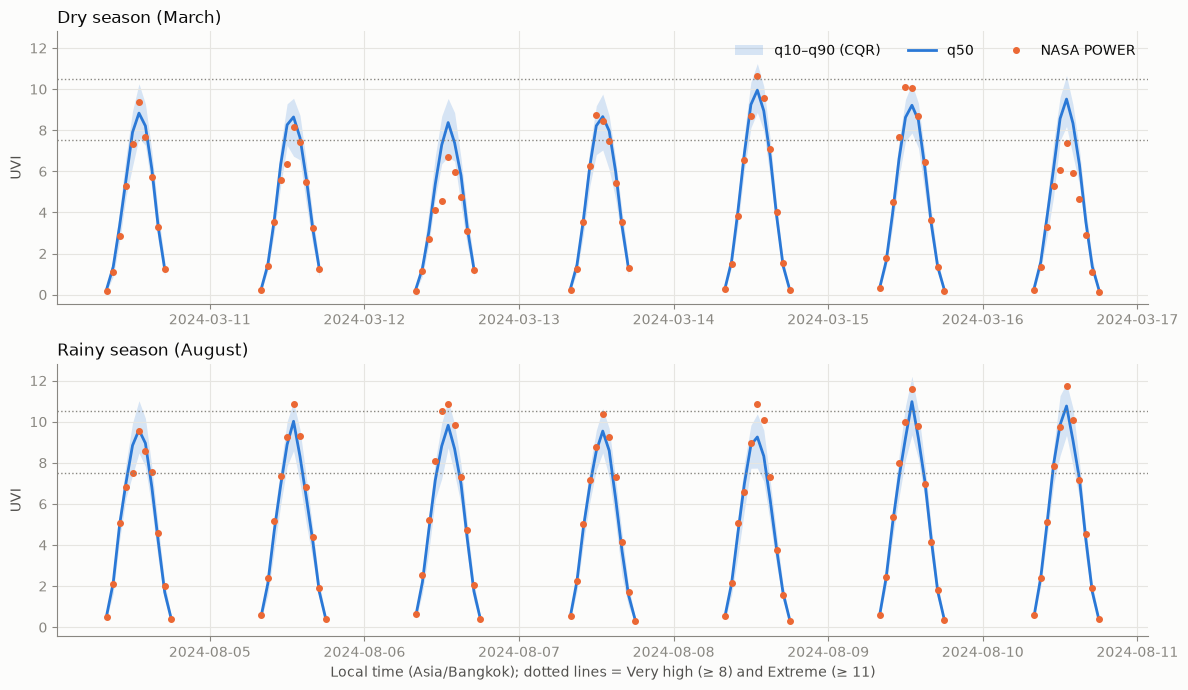

In [5]:
local = dev["time_utc"].dt.tz_convert("Asia/Bangkok")
weeks = [("2024-03-10", "Dry season (March)"), ("2024-08-04", "Rainy season (August)")]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharey=True)
for ax, (start, title) in zip(axes, weeks):
    s = pd.Timestamp(start, tz="Asia/Bangkok")
    sel = (local >= s) & (local < s + pd.Timedelta(days=7))
    t = local[sel]
    # break the band at night gaps so it does not bridge across days
    day = t.dt.date
    for d in day.unique():
        k = (day == d).to_numpy()
        idx = sel[sel].index[k]
        ax.fill_between(t[k], uvi_q.loc[idx, "q10"], uvi_q.loc[idx, "q90"], color=C_OM, alpha=0.18, lw=0,
                        label="q10–q90 (CQR)" if d == day.iloc[0] else None)
        ax.plot(t[k], uvi_q.loc[idx, "q50"], color=C_OM, lw=2, label="q50" if d == day.iloc[0] else None)
        ax.plot(t[k], dev.loc[idx, "nasa_uvi"], color=C_NASA, lw=0, marker="o", ms=4,
                label="NASA POWER" if d == day.iloc[0] else None)
    ax.axhline(7.5, color=MUTED, ls=":", lw=1)
    ax.axhline(10.5, color=MUTED, ls=":", lw=1)
    ax.set_title(title, loc="left")
    ax.set_ylabel("UVI")
axes[0].legend(loc="upper right", ncol=3)
axes[1].set_xlabel("Local time (Asia/Bangkok); dotted lines = Very high (≥ 8) and Extreme (≥ 11)")
fig.tight_layout()
save(fig, "quantile_examples.png")

## 3. การเตือน: q50 vs q75 vs q90

เตือน "สูงมากขึ้นไป" เมื่อระดับของ quantile ≥ 8 และเตือน "รุนแรงมาก" เมื่อ ≥ 11 (ปัดเป็นจำนวนเต็มแบบ WHO)

In [6]:
show = ["quantile", "level", "n_events", "n_alerts", "tp", "fp", "fn", "recall", "precision", "false_alarm_rate"]
print("CV folds 3-5 pooled (selection):")
display(alerts_cv[show].round(3))
print("dev 2024 (train 2023, optimistic):")
display(alerts_dev[show].round(3))

CV folds 3-5 pooled (selection):


,quantile,level,n_events,n_alerts,tp,fp,fn,recall,precision,false_alarm_rate
0,q50,Very high,704,773,591,182,113,0.839,0.765,0.060
1,q50,Extreme,53,10,6,4,47,0.113,0.600,0.001
2,q75,Very high,704,891,652,239,52,0.926,0.732,0.079
3,q75,Extreme,53,14,7,7,46,0.132,0.500,0.002
4,q90,Very high,704,1168,696,472,8,0.989,0.596,0.157
5,q90,Extreme,53,99,33,66,20,0.623,0.333,0.018


dev 2024 (train 2023, optimistic):


,quantile,level,n_events,n_alerts,tp,fp,fn,recall,precision,false_alarm_rate
0,q50,Very high,704,778,595,183,109,0.845,0.765,0.061
1,q50,Extreme,53,10,6,4,47,0.113,0.600,0.001
2,q75,Very high,704,895,651,244,53,0.925,0.727,0.081
3,q75,Extreme,53,15,7,8,46,0.132,0.467,0.002
4,q90,Very high,704,1213,699,514,5,0.993,0.576,0.170
5,q90,Extreme,53,132,37,95,16,0.698,0.280,0.026


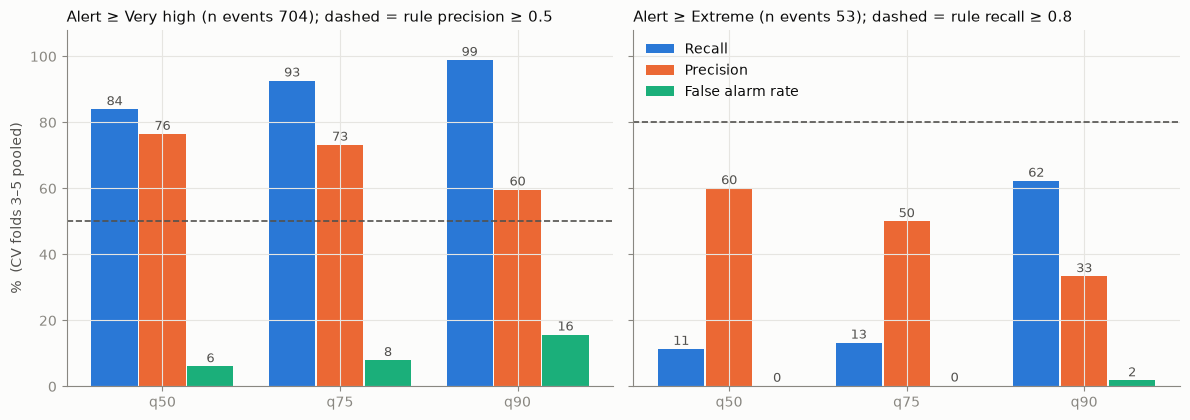

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
metrics = [("recall", "Recall", C_OM), ("precision", "Precision", C_NASA),
           ("false_alarm_rate", "False alarm rate", C_THIRD)]
for ax, lvl, rule in [(axes[0], "Very high", ("precision", 0.5)), (axes[1], "Extreme", ("recall", 0.8))]:
    t = alerts_cv[alerts_cv["level"] == lvl].set_index("quantile").loc[qr.ALERT_CANDIDATES]
    x = np.arange(len(t))
    w = 0.26
    for i, (col, lab, c) in enumerate(metrics):
        vals = t[col].to_numpy() * 100
        ax.bar(x + (i - 1) * (w + 0.01), vals, width=w, color=c, label=lab)
        for xi, v in zip(x + (i - 1) * (w + 0.01), vals):
            ax.annotate(f"{v:.0f}", (xi, v), textcoords="offset points", xytext=(0, 3), ha="center",
                        color=INK2, fontsize=9)
    ax.axhline(rule[1] * 100, color=INK2, ls="--", lw=1.2)
    ax.set_xticks(x, t.index)
    ax.set_title(f"Alert ≥ {lvl} (n events {int(t['n_events'].iloc[0])}); dashed = rule {rule[0]} ≥ {rule[1]:.1f}",
                 loc="left", fontsize=11)
    ax.set_ylim(0, 108)
axes[0].set_ylabel("%  (CV folds 3–5 pooled)")
axes[1].legend(loc="upper left")
fig.tight_layout()
save(fig, "quantile_alerts.png")

### Confusion matrix ของระดับ WHO เมื่อใช้ q90 (CQR) บน dev 2024 (แถว = ค่าจริง)

In [8]:
cm = pd.DataFrame(m["dev_2024"]["served"]["who_q90"]["confusion"], index=qr.WHO_LEVELS_EN, columns=qr.WHO_LEVELS_EN)
display(cm)
rec = m["dev_2024"]["served"]["who_q90"]["recall"]
print(f"recall (exact level) Very high {rec['Very high']:.3f}, Extreme {rec['Extreme']:.3f}")

,Low,Moderate,High,Very high,Extreme
Low,1076,196,4,1,0
Moderate,0,651,270,56,0
High,0,3,308,455,2
Very high,0,0,5,553,93
Extreme,0,0,0,16,37


recall (exact level) Very high 0.849, Extreme 0.698


## สรุป

**Coverage ของช่วง [q10, q90]**
- **ช่วงดิบแคบเกินไป:** coverage บน CV fold 3–5 = **0.593** และ dev 2024 = 0.578 ต่ำกว่าเกณฑ์ 0.75 ค่าจริงหลุดด้านล่าง 23–25 % และด้านบน 17 % แสดงว่า quantile ของ XGBoost ประเมินความแปรปรวนต่ำไป จึงใช้ **CQR** ตามกฎ
- **ตรวจ CQR:** Q จาก fold 3–4 = +0.043 (CMF) ทำให้ coverage ของ fold 5 เปลี่ยนจาก 0.652 เป็น **0.863** (เกินขอบบน 0.85 เล็กน้อย) บน dev 2024 ใช้ Q จากปี 2023 (+0.050) ได้ **0.837** ผ่านเกณฑ์ แต่ช่วงกว้างขึ้นจาก 0.81 เป็น 1.50 UVI ส่วน Q ของโมเดลสุดท้าย (fold 3–5) คือ **+0.038**
- **coverage ไม่สม่ำเสมอ:**
  - ตามระดับ q50 ที่ทำนาย: ต่ำ 0.86, ปานกลาง 0.88, สูง 0.83, **สูงมาก 0.76**, รุนแรงมาก 0.70 (n = 10)
  - ตามเดือน: 0.73 (มี.ค., ก.ค.) ถึง 0.96 (ม.ค., ธ.ค.)
  - สาเหตุคือ Q เป็นค่าคงที่บนสเกล CMF ทำให้ชั่วโมงที่ต้องเตือนได้ coverage ต่ำกว่าค่าเฉลี่ย **จดเป็นข้อจำกัด** ทางแก้ในอนาคตคือใช้ Q แยกตามระดับ (Mondrian CQR)
  - หลัง CQR ค่าจริงหลุดด้านล่างมากกว่าด้านบน (12 % เทียบกับ 4 %) ช่วงจึงเอียงไปทางค่าสูง ซึ่งปลอดภัยกว่าสำหรับการเตือน

**การเตือน (CV fold 3–5 รวมกัน; ≥ สูงมาก 704 ชม., รุนแรงมาก 53 ชม.)**

| quantile | ≥ สูงมาก recall / precision / FAR | รุนแรงมาก recall / precision / FAR |
|---|---|---|
| q50 | 0.84 / 0.76 / 0.06 | 0.11 / 0.60 / 0.001 |
| q75 | 0.93 / 0.73 / 0.08 | 0.13 / 0.50 / 0.002 |
| q90 (CQR) | **0.99** / 0.60 / 0.16 | **0.62** / 0.33 / 0.018 |

- **ไม่มี quantile ไหนผ่านเกณฑ์** (recall รุนแรงมาก ≥ 0.8 และ precision ≥ สูงมาก ≥ 0.5) → **ใช้ q90 ตาม rules** ตอนนี้ q90 ผ่านเงื่อนไข precision (0.60) แต่ recall รุนแรงมากได้แค่ 0.62
- **สาเหตุ:**
  - ชั่วโมงระดับรุนแรงมากมีค่าเฉลี่ย 10.98 ซึ่งอยู่เหนือเส้นแบ่ง 10.5 เพียงเล็กน้อย (วัน 7)
  - q75 แทบไม่ต่างจาก q50 เพราะช่วงดิบแคบ ส่วนที่ทำให้ q90 ข้าม 11 ได้คือการขยายช่วงด้วย CQR
- **ถึงแม้ป้ายรุนแรงมากจะพลาด ชั่วโมงรุนแรงมากก็ยังได้รับการเตือน:** บน dev 2024 ชั่วโมงรุนแรงมากทั้ง 53 ชม. ถูกทำนายด้วย q90 เป็นอย่างน้อยระดับ**สูงมาก** (37 ชม. เป็นรุนแรงมาก และ 16 ชม. เป็นสูงมาก) ดังนั้นการเตือน "≥ สูงมาก" ด้วย q90 จับได้ครบทุกชั่วโมง
- **ราคาที่ต้องจ่าย:** 16 % ของชั่วโมงที่จริงไม่ถึงระดับสูงมากจะได้รับการเตือน และการเตือนสูงมาก 40 % เป็น false alarm สำหรับการเตือนด้านสุขภาพ (ให้ความสำคัญกับการไม่พลาด) ถือว่ายอมรับได้ แต่ต้องใช้ cooldown และ hysteresis ในวัน 22 เพื่อไม่ให้ผู้ใช้ถูกเตือนถี่เกินไป

⚠️ ตัวเลข dev 2024 มี optimistic bias จากการ tune ในวัน 8 ตัวเลขจริงคือ test 2025 ในวัน 10